In [1]:
from keras.layers import Input, Lambda, Dense, Flatten , GlobalAveragePooling2D
from keras.models import Model
from keras.applications.densenet import DenseNet121
from keras.applications.densenet import preprocess_input
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import tensorflow as tf

# Configure GPU memory growth to prevent OOM errors
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"[OK] GPU memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)


[OK] GPU memory growth enabled for 1 GPU(s)


In [2]:
# data loading by using keras with automatic train/validation split
# Reduced batch_size to 16 to prevent GPU memory issues
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

training_set = train_datagen.flow_from_directory(
    'removed background',
    target_size=(224, 224),
    batch_size=16,  # Reduced from 32 to prevent OOM
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)


Found 4215 images belonging to 20 classes.


In [3]:
validation_set = train_datagen.flow_from_directory(
    'removed background',
    target_size=(224, 224),
    batch_size=16,  # Reduced from 32 to prevent OOM
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=42
)


Found 1046 images belonging to 20 classes.


In [4]:
# Load the base model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


In [5]:
# Freeze all the dense layers
for layer in base_model.layers:
    layer.trainable = False


In [6]:
# Define the model
from tensorflow.keras.layers import Dropout , GlobalAveragePooling2D
model = Sequential([
    base_model,
    GlobalAveragePooling2D(), # flatten()
    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(20, activation='softmax')
])


In [7]:
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet121 (Functional)    (None, 7, 7, 1024)        7037504   
                                                                 
 global_average_pooling2d (G  (None, 1024)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 1024)              1049600   
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 20)                20500     
                                                                 
Total params: 8,107,604
Trainable params: 1,070,100
Non-trainable params: 7,037,504
______________________________________

In [8]:
# Compile the model
from tensorflow.keras.optimizers import Adam
# Reduced learning rate slightly for DenseNet121 to help with overfitting
model.compile(optimizer=Adam(learning_rate=5e-6), loss='categorical_crossentropy', metrics=['accuracy'])


In [9]:
from keras.callbacks import EarlyStopping, ModelCheckpoint
from pathlib import Path

# Create callbacks list
callback = [
    EarlyStopping(
        monitor="val_accuracy",
        min_delta=0.00001,
        patience=45,
        verbose=1,
        mode="auto",
        baseline=None,
        restore_best_weights=True # false
    ),
    ModelCheckpoint(
        filepath="DenseNet121_best_model.keras",
        monitor="val_accuracy",
        verbose=1,
        save_best_only=True,
        mode="max",  # Changed to "max" because higher accuracy is better
        save_weights_only=False
    )
]


In [10]:
# Fit the model
training_model=model.fit(training_set, epochs=150, validation_data=validation_set , callbacks=callback)


Epoch 1/150
264/264 [==============================] - ETA: 0s - loss: 3.1915 - accuracy: 0.0724
Epoch 1: val_accuracy improved from -inf to 0.16539, saving model to DenseNet121_best_model.keras
264/264 [==============================] - 180s 661ms/step - loss: 3.1915 - accuracy: 0.0724 - val_loss: 2.7688 - val_accuracy: 0.1654
Epoch 2/150
264/264 [==============================] - ETA: 0s - loss: 2.8426 - accuracy: 0.1350
Epoch 2: val_accuracy improved from 0.16539 to 0.35468, saving model to DenseNet121_best_model.keras
264/264 [==============================] - 139s 528ms/step - loss: 2.8426 - accuracy: 0.1350 - val_loss: 2.5103 - val_accuracy: 0.3547
Epoch 3/150
264/264 [==============================] - ETA: 0s - loss: 2.6100 - accuracy: 0.2081
Epoch 3: val_accuracy improved from 0.35468 to 0.43499, saving model to DenseNet121_best_model.keras
264/264 [==============================] - 134s 510ms/step - loss: 2.6100 - accuracy: 0.2081 - val_loss: 2.3188 - val_accuracy: 0.4350
Epoc

In [11]:
# model evaluation on training set
training_set.reset()
training_loss , train_accuracy = model.evaluate(training_set)


264/264 [==============================] - 104s 395ms/step - loss: 0.1653 - accuracy: 0.9668


In [12]:
# model evaluation on validation set
validation_set.reset()
validation_loss , validation_accuracy = model.evaluate(validation_set)


66/66 [==============================] - 28s 413ms/step - loss: 0.6623 - accuracy: 0.8126


In [13]:
tf.keras.callbacks.History()


In [14]:
training_model.history


{'loss': [3.1914589405059814,
  2.842630624771118,
  2.6099894046783447,
  2.401257276535034,
  2.2214787006378174,
  2.077404260635376,
  1.9490809440612793,
  1.8275609016418457,
  1.7324018478393555,
  1.6256377696990967,
  1.5429811477661133,
  1.4723325967788696,
  1.4028948545455933,
  1.357328176498413,
  1.2891509532928467,
  1.2528489828109741,
  1.2055991888046265,
  1.175851821899414,
  1.1186774969100952,
  1.0864125490188599,
  1.0660046339035034,
  1.0271892547607422,
  1.0033701658248901,
  0.9542462825775146,
  0.9218077063560486,
  0.8938466906547546,
  0.87474125623703,
  0.8605908751487732,
  0.8452499508857727,
  0.8160203099250793,
  0.7871885299682617,
  0.7878080606460571,
  0.7614888548851013,
  0.747323751449585,
  0.739147424697876,
  0.723351776599884,
  0.7050725817680359,
  0.6921378374099731,
  0.6762863397598267,
  0.6666578650474548,
  0.6424979567527771,
  0.6361070871353149,
  0.622743546962738,
  0.6141515374183655,
  0.6033169627189636,
  0.595640540

In [15]:
# record the history in json format

import json
with open("training_hist_DenseNet121_version_2.json" , "w") as f:
    json.dump(training_model.history , f)


In [16]:
# viz
# Create epochs list based on actual number of epochs trained (not fixed 150)
epochs = list(range(1, len(training_model.history['accuracy']) + 1))
epochs


[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150]

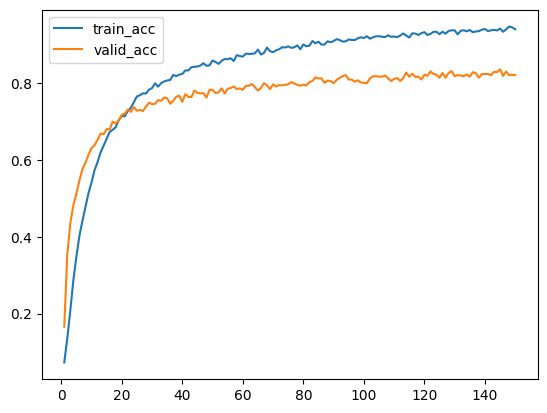

In [17]:
plt.plot(epochs,training_model.history['accuracy'] , label = 'train_acc')
plt.plot(epochs,training_model.history['val_accuracy'] , label='valid_acc')
plt.legend()
plt.show()


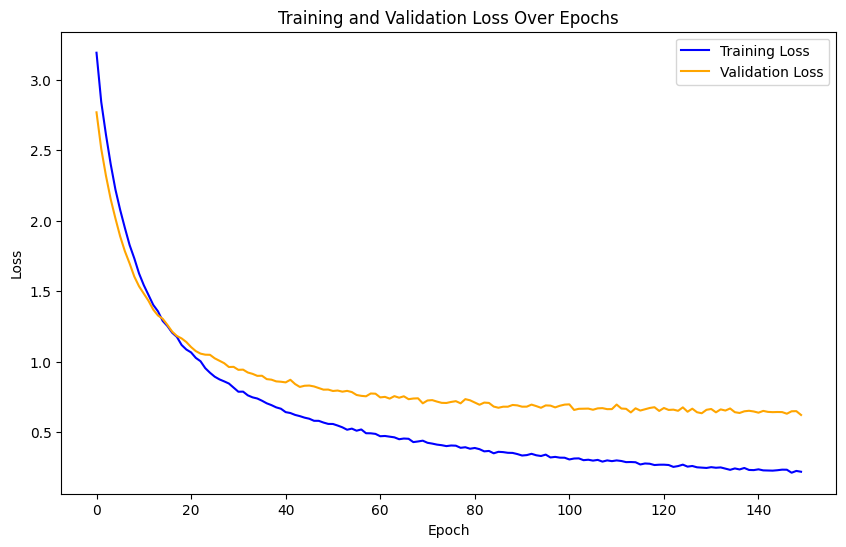

In [18]:
import json
import matplotlib.pyplot as plt

# Load the JSON data from the file
with open("training_hist_DenseNet121_version_2.json") as f:
    data = json.load(f)

# Extract loss and validation loss
loss = data['loss']
val_loss = data['val_loss']

# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')

# Add titles and labels
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.show()


In [19]:
class_name = list(training_set.class_indices.keys())
class_name


['Aloevera',
 'Amla',
 'Bamboo',
 'Bhrami',
 'Bringaraja',
 'Castor',
 'Coffee',
 'Coriender',
 'Curry',
 'Eucalyptus',
 'Ginger',
 'Guava',
 'Henna',
 'Hibiscus',
 'Lemon',
 'Mint',
 'Neem',
 'Onion',
 'Palak(Spinach)',
 'Papaya']

In [20]:
# Create test set for evaluation (without augmentation)
test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

test_set = test_datagen.flow_from_directory(
    'removed background',
    target_size=(224, 224),
    batch_size=16,  # Reduced from 32 to prevent OOM
    class_mode='categorical',
    subset='validation',
    shuffle=False,# one by one check all the directory
    seed=42
)


Found 1046 images belonging to 20 classes.


In [ ]:
y_pred = model.predict(test_set)
y_pred


66/66 [==============================] - 23s 336ms/step


array([[9.9996722e-01, 5.6938081e-08, 7.1676113e-06, ..., 3.8726941e-07,
        1.5889875e-06, 7.7737491e-07],
       [9.3668669e-01, 4.7066020e-05, 3.5472176e-04, ..., 9.5376563e-05,
        1.0122869e-04, 2.4592262e-05],
       [9.4454980e-01, 4.7985643e-05, 2.9128575e-04, ..., 8.3711675e-05,
        8.5663662e-05, 1.9944875e-05],
       ...,
       [6.6168614e-06, 8.4258503e-11, 5.1982543e-09, ..., 4.5164683e-07,
        2.6736586e-09, 9.9343610e-01],
       [5.4420016e-06, 9.2558086e-11, 2.7826648e-09, ..., 4.2825351e-07,
        1.0020871e-09, 9.9605858e-01],
       [1.0452568e-05, 3.8546322e-10, 2.7020686e-08, ..., 2.5103343e-06,
        4.7924051e-09, 9.6896273e-01]], dtype=float32)

In [22]:
predicted_categories= tf.argmax(y_pred,axis=1)


In [ ]:
# Reset test_set before reading labels (it was already used for predictions)
test_set.reset()
true_categories = tf.concat([y for x,y in test_set] , axis=0)
true_categories #one hot encoding


KeyboardInterrupt: 

In [ ]:
y_true= tf.argmax(true_categories,axis=1)
y_true


In [ ]:
from sklearn.metrics import classification_report , confusion_matrix
print(classification_report(y_true,predicted_categories ,target_names = class_name))


In [ ]:
cm = confusion_matrix(y_true , predicted_categories)
cm.shape


In [ ]:
import seaborn as sns
plt.figure(figsize = (12,6))
sns.heatmap(cm,linewidth=0.5, cmap='summer')
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.show()


In [ ]:
import seaborn as sns
plt.figure(figsize = (12,6))
sns.heatmap(cm,linewidth=0.5, cmap='summer' ,annot=True)
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.show()
